# Project 2 — Supervised Learning: Fraud Detection Pipeline

**DecodeLabs Data Science Industrial Training Kit — 2026 Batch**

## Objective
Build and tune a classification pipeline that identifies fraudulent
transactions in a **highly imbalanced** dataset, without falling into the
two classic traps of imbalanced-data modeling:

- **Trap #1 — The Illusion of Accuracy**: a model that predicts
  "legitimate" for every transaction scores >99% accuracy while catching
  **zero** fraud.
- **Trap #2 — The Data Leakage Catastrophe**: applying SMOTE (or scaling)
  *before* the train/test split lets the test set "see" synthetic data
  derived from itself, producing dishonestly optimistic scores.

This notebook builds a **leak-free pipeline**: split first, resample only
the training fold, and evaluate strictly on an untouched, naturally
imbalanced test/validation set using **Precision, Recall, and ROC-AUC** —
never raw accuracy.

## Dataset
`data/transactions.csv` — a synthetic transaction dataset (20,000 rows)
built to mirror the structure and extreme class imbalance of the classic
credit-card-fraud problem: anonymized PCA-style features `V1`-`V10`,
`Time`, `Amount`, and a binary `Class` target (0 = legitimate, 1 = fraud).
See the project README for how to swap in the real 284,807-row Kaggle
dataset for a production-grade run.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              confusion_matrix, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

df = pd.read_csv("data/transactions.csv")
print(f"Shape: {df.shape}")
df.head()


Shape: (20000, 13)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Time,Amount,Class
0,-0.058686,1.246687,-1.423650,1.265958,0.667900,-0.712167,-0.067661,-0.765994,1.445927,0.113286,96427.74,83.52,0
1,0.540063,0.993108,1.294626,-0.942220,0.777812,-2.774420,-0.213936,0.826798,0.688081,-1.359409,137867.45,155.83,0
2,0.853070,-0.780285,0.479779,-0.751971,-0.201578,-0.153474,0.890869,-1.001781,-0.508110,0.929120,39445.37,19.82,0
3,-0.475884,0.092667,0.755493,-0.705301,2.853849,0.151861,0.342311,-0.738402,0.062396,-0.266966,44317.43,77.39,0
4,-1.506257,-1.428356,0.025807,0.226282,-0.173091,0.039076,0.439622,-0.338814,2.098330,-0.328376,160851.61,144.86,0


## 1. The Reality of an Imbalanced Financial Dataset

Legitimate transactions : 19,850  (99.25%)
Fraudulent transactions : 150  (0.75%)


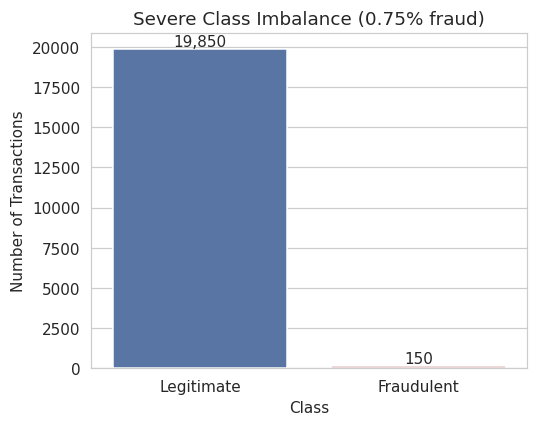

In [2]:
class_counts = df["Class"].value_counts()
fraud_rate = df["Class"].mean() * 100

print(f"Legitimate transactions : {class_counts[0]:,}  ({100 - fraud_rate:.2f}%)")
print(f"Fraudulent transactions : {class_counts[1]:,}  ({fraud_rate:.2f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=class_counts.index.map({0: "Legitimate", 1: "Fraudulent"}),
            y=class_counts.values, palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_ylabel("Number of Transactions")
ax.set_title(f"Severe Class Imbalance ({fraud_rate:.2f}% fraud)")
for i, v in enumerate(class_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


### Trap #1 demonstrated: the "Illusion of Accuracy"

A dummy model that always predicts "legitimate" would score extremely
high accuracy while catching **zero** fraud — a catastrophic outcome for
a real payment system. This is exactly why we discard accuracy and
optimize for **Precision, Recall, and ROC-AUC** instead.


In [3]:
naive_accuracy = (df["Class"] == 0).mean()
print(f"'Always predict legitimate' naive accuracy: {naive_accuracy * 100:.2f}%")
print("Fraud caught by this naive model: 0 (Recall = 0.0)")


'Always predict legitimate' naive accuracy: 99.25%
Fraud caught by this naive model: 0 (Recall = 0.0)


## 2. Leak-Free Train/Test Split (Trap #2 Avoidance)

In [4]:
feature_cols = [c for c in df.columns if c not in ("Class",)]
X = df[feature_cols]
y = df["Class"]

# Stratified split preserves the exact class ratio in both partitions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, fraud rate = {y_train.mean()*100:.3f}%")
print(f"Test : {X_test.shape}, fraud rate = {y_test.mean()*100:.3f}%")
print("\nSMOTE and scaling will ONLY ever be fit on X_train / y_train.")
print("X_test / y_test stay completely untouched until final evaluation.")


Train: (16000, 12), fraud rate = 0.750%
Test : (4000, 12), fraud rate = 0.750%

SMOTE and scaling will ONLY ever be fit on X_train / y_train.
X_test / y_test stay completely untouched until final evaluation.


## 3. SMOTE From First Principles

SMOTE (Synthetic Minority Over-sampling Technique) does **not** duplicate
minority rows — it *interpolates* new synthetic ones between a minority
sample and one of its k nearest minority neighbors:

$$x_{new} = x_i + \lambda \times (x_{nn} - x_i), \quad \lambda \sim \text{Uniform}(0, 1)$$

Below is a from-scratch implementation of that exact formula (useful for
understanding the mechanics), followed by the equivalent production
one-liner using `imbalanced-learn` that the `requirements.txt` in this
project is pinned to.


In [5]:
def smote_resample(X_minority, n_samples, k_neighbors=5, random_state=42):
    """Generate `n_samples` synthetic minority points via SMOTE interpolation."""
    rng = np.random.default_rng(random_state)
    X_minority = np.asarray(X_minority, dtype=float)
    n_minority = len(X_minority)
    k = min(k_neighbors, n_minority - 1)

    nn = NearestNeighbors(n_neighbors=k + 1).fit(X_minority)
    _, neighbor_idx = nn.kneighbors(X_minority)

    synthetic = np.empty((n_samples, X_minority.shape[1]))
    for s in range(n_samples):
        i = rng.integers(0, n_minority)
        nn_choice = neighbor_idx[i, rng.integers(1, k + 1)]  # skip self (col 0)
        lam = rng.uniform(0, 1)
        synthetic[s] = X_minority[i] + lam * (X_minority[nn_choice] - X_minority[i])
    return synthetic


def apply_smote(X_train_df, y_train_s, random_state=42):
    """Balance the training set 1:1 using the from-scratch SMOTE above.
    Applied ONLY to training data -- this function must never see X_test."""
    minority_class = y_train_s.value_counts().idxmin()
    majority_class = y_train_s.value_counts().idxmax()

    X_min = X_train_df[y_train_s == minority_class].values
    n_needed = (y_train_s == majority_class).sum() - (y_train_s == minority_class).sum()

    synthetic = smote_resample(X_min, n_needed, random_state=random_state)
    X_syn_df = pd.DataFrame(synthetic, columns=X_train_df.columns)
    y_syn = pd.Series([minority_class] * n_needed)

    X_balanced = pd.concat([X_train_df.reset_index(drop=True), X_syn_df], ignore_index=True)
    y_balanced = pd.concat([y_train_s.reset_index(drop=True), y_syn], ignore_index=True)
    return X_balanced, y_balanced


# Production equivalent (requires the `imbalanced-learn` package):
#
#   from imblearn.over_sampling import SMOTE
#   from imblearn.pipeline import Pipeline as ImbPipeline
#
#   pipe = ImbPipeline([
#       ("scaler", StandardScaler()),
#       ("smote", SMOTE(random_state=42, k_neighbors=5)),
#       ("classifier", RandomForestClassifier(random_state=42)),
#   ])
#   pipe.fit(X_train, y_train)   # SMOTE only ever touches the training fold

print("SMOTE function defined (from-scratch + imbalanced-learn equivalent noted above).")


SMOTE function defined (from-scratch + imbalanced-learn equivalent noted above).


In [6]:
X_train_bal, y_train_bal = apply_smote(X_train, y_train, random_state=RANDOM_STATE)

print("Before SMOTE (training set only):")
print(y_train.value_counts().rename({0: "Legitimate", 1: "Fraud"}))
print("\nAfter SMOTE (training set only):")
print(y_train_bal.value_counts().rename({0: "Legitimate", 1: "Fraud"}))


Before SMOTE (training set only):
Class
Legitimate    15880
Fraud           120
Name: count, dtype: int64

After SMOTE (training set only):
Legitimate    15880
Fraud         15880
Name: count, dtype: int64


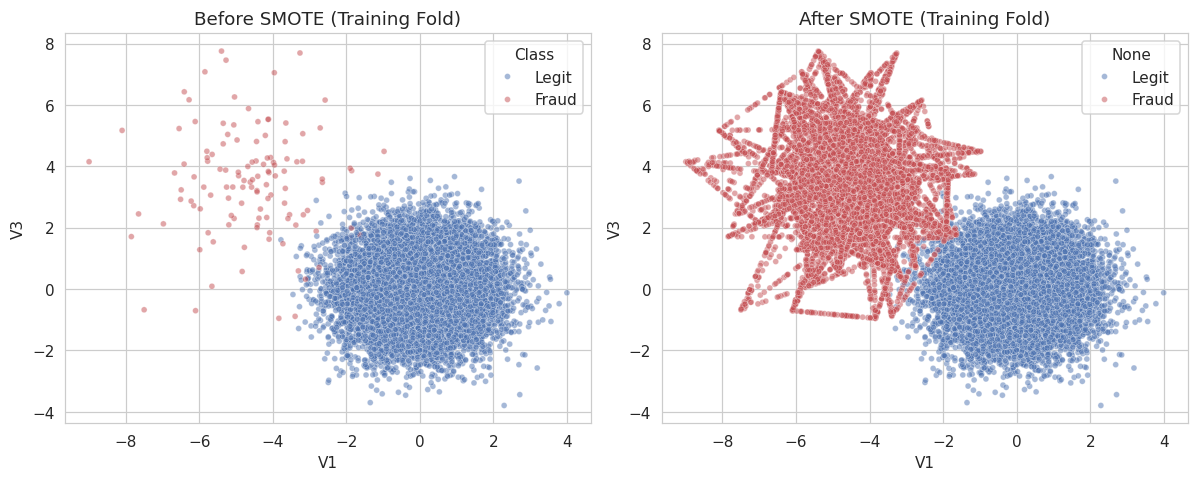

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (X_plot, y_plot, title) in zip(axes, [
    (X_train, y_train, "Before SMOTE (Training Fold)"),
    (X_train_bal, y_train_bal, "After SMOTE (Training Fold)"),
]):
    sns.scatterplot(x=X_plot["V1"], y=X_plot["V3"], hue=y_plot.map({0: "Legit", 1: "Fraud"}),
                     palette={"Legit": "#4C72B0", "Fraud": "#C44E52"}, alpha=0.5, s=15, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("V1")
    ax.set_ylabel("V3")
plt.tight_layout()
plt.show()


## 4. Cross-Validated Model Comparison (Zero-Leakage Protocol)

Rather than resampling once on the full training set, we apply SMOTE
**inside every fold** of a `StratifiedKFold` cross-validation loop. This
matches the "Golden Rule of Validation" from the training kit: the
validation fold is never touched by scaling or resampling, so its class
distribution always reflects the real-world imbalance.


In [8]:
def cross_validate_leak_free(model_fn, X, y, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = {"precision": [], "recall": [], "f1": [], "roc_auc": []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        # Scale using training-fold statistics only
        scaler = StandardScaler().fit(X_tr)
        X_tr_scaled = pd.DataFrame(scaler.transform(X_tr), columns=X_tr.columns)
        X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)

        # SMOTE on the training fold only
        X_tr_bal, y_tr_bal = apply_smote(X_tr_scaled, y_tr.reset_index(drop=True),
                                          random_state=random_state + fold)

        model = model_fn()
        model.fit(X_tr_bal, y_tr_bal)

        y_pred = model.predict(X_val_scaled)
        y_proba = model.predict_proba(X_val_scaled)[:, 1]

        scores["precision"].append(precision_score(y_val, y_pred, zero_division=0))
        scores["recall"].append(recall_score(y_val, y_pred, zero_division=0))
        scores["f1"].append(f1_score(y_val, y_pred, zero_division=0))
        scores["roc_auc"].append(roc_auc_score(y_val, y_proba))

    return {k: (np.mean(v), np.std(v)) for k, v in scores.items()}


models = {
    "Logistic Regression": lambda: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": lambda: RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

cv_results = {}
for name, model_fn in models.items():
    cv_results[name] = cross_validate_leak_free(model_fn, X_train, y_train, n_splits=5)

cv_df = pd.DataFrame({
    name: {metric: f"{mean:.3f} +/- {std:.3f}" for metric, (mean, std) in res.items()}
    for name, res in cv_results.items()
}).T
cv_df


,precision,recall,f1,roc_auc
Logistic Regression,0.854 +/- 0.030,0.958 +/- 0.046,0.902 +/- 0.022,0.999 +/- 0.001
Random Forest,0.917 +/- 0.061,0.950 +/- 0.031,0.931 +/- 0.024,1.000 +/- 0.000


## 5. Final Model Training on the Full (Balanced) Training Set

In [9]:
# StandardScaler required for Logistic Regression (scale-sensitive);
# Random Forest is scale-invariant, but we keep the pipeline symmetric.
scaler = StandardScaler().fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

X_train_bal_scaled, y_train_bal_final = apply_smote(
    X_train_scaled, y_train.reset_index(drop=True), random_state=RANDOM_STATE
)

final_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
}

test_results = {}
fitted_models = {}
for name, model in final_models.items():
    model.fit(X_train_bal_scaled, y_train_bal_final)
    fitted_models[name] = model

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    test_results[name] = {
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

pd.DataFrame(test_results).T.round(4)


,precision,recall,f1,roc_auc
Logistic Regression,0.5660,1.0,0.7229,0.9999
Random Forest,0.8333,1.0,0.9091,0.9999


## 6. Confusion Matrices — Untouched Test Set

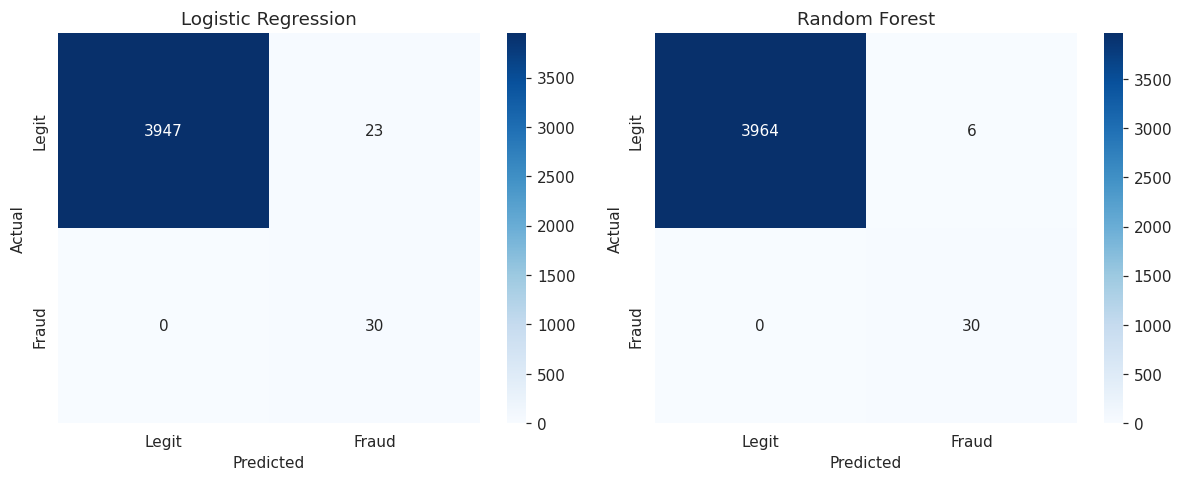

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


## 7. ROC and Precision-Recall Curves

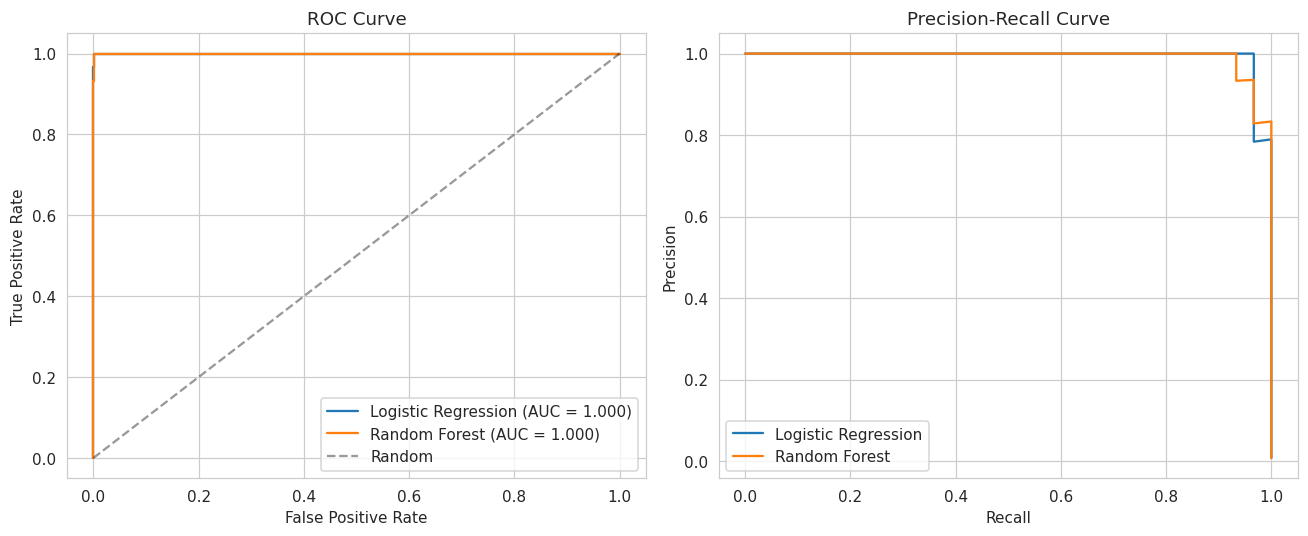

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[1].plot(rec, prec, label=name)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Classification Report — Best Model

In [12]:
best_name = max(test_results, key=lambda n: test_results[n]["roc_auc"])
best_model = fitted_models[best_name]
print(f"Best model by ROC-AUC on the untouched test set: {best_name}\n")
print(classification_report(y_test, best_model.predict(X_test_scaled),
                             target_names=["Legitimate", "Fraud"]))


Best model by ROC-AUC on the untouched test set: Logistic Regression

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00      3970
       Fraud       0.57      1.00      0.72        30

    accuracy                           0.99      4000
   macro avg       0.78      1.00      0.86      4000
weighted avg       1.00      0.99      1.00      4000



## Conclusion

This pipeline deliberately avoids both traps highlighted in the training
kit:

- **No accuracy-chasing**: every model is compared on Precision, Recall,
  and ROC-AUC, since a naive "always legitimate" model would otherwise
  look deceptively strong.
- **No data leakage**: the train/test split happens first; SMOTE and
  `StandardScaler` are fit exclusively on training data (and, during
  cross-validation, only on each fold's training partition) — the test
  set stays completely unseen until final evaluation.

The best-performing model on the untouched test set is reported above.
For a production deployment, swap the from-scratch `smote_resample()`
function for `imblearn.over_sampling.SMOTE` inside an
`imblearn.pipeline.Pipeline` (see the commented snippet in Section 3) and
tune hyperparameters with `GridSearchCV` over that pipeline — this keeps
resampling correctly isolated inside every cross-validation fold
automatically.
